# EDA — Curated BUSI

Análise exploratória leve do dataset **Curated BUSI** (ultrassom de mama), cobrindo cada etapa do
pipeline: `raw/` → `processed_128/` → partição federada.

Objetivo: quantidade total de dados em cada etapa, balanceamento de classes, características das
imagens e alguns exemplos.

O notebook é **independente do `src/config.yaml` ativo**: ele fixa `dataset='Curated_BUSI'`, então
roda mesmo que o config esteja apontando para outro dataset.

In [1]:
import os, sys
from pathlib import Path

# Notebook vive em scripts/, mas os caminhos do mapping.csv são relativos à raiz do repo.
ROOT = Path.cwd()
while not (ROOT / 'src' / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('repo root:', ROOT)

%matplotlib inline

import cv2
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from src.dataset import paths

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 140)

# Fixa o dataset em vez de herdar o config ativo.
config = yaml.safe_load(open('src/config.yaml'))
data_cfg = dict(config['data'], dataset='Curated_BUSI', variant='processed_128')

CLASSES = ['benign', 'malignant', 'normal']
COLORS = {'benign': '#4C9F70', 'malignant': '#C1666B', 'normal': '#6C8EBF'}

print('dataset  :', paths.dataset_dir(data_cfg))
print('variant  :', paths.processed_dir(data_cfg))
print('partition:', paths.partition_file(data_cfg))

repo root: /home/lucas/fed_multi_task_breast_cancer


dataset  : data/Curated_BUSI
variant  : data/Curated_BUSI/processed_128
partition: data/Curated_BUSI/federated/federated_mapping.csv


## 1. Quantidade de dados em cada etapa

Três etapas: o `raw/` que o preprocessing lê, o variant `processed_128/` que o treino lê, e a
partição federada congelada.

In [2]:
raw_dir = paths.raw_dir(data_cfg)

rows = []
for cls in CLASSES:
    files = list((raw_dir / cls).glob('*.png'))
    imgs = [f for f in files if 'mask' not in f.name]
    masks = [f for f in files if 'mask' in f.name]
    extra = [f for f in files if 'mask_1' in f.name]
    rows.append({'classe': cls, 'arquivos': len(files), 'imagens': len(imgs),
                 'máscaras': len(masks), 'máscaras extras (_mask_1)': len(extra)})

raw_counts = pd.DataFrame(rows)
raw_counts.loc['TOTAL'] = raw_counts.sum(numeric_only=True)
raw_counts.loc['TOTAL', 'classe'] = 'TOTAL'
raw_counts

,classe,arquivos,imagens,máscaras,máscaras extras (_mask_1)
0,benign,444.0,222.0,222.0,0.0
1,malignant,328.0,164.0,164.0,0.0
2,normal,128.0,64.0,64.0,0.0
TOTAL,TOTAL,900.0,450.0,450.0,0.0


> **Observação sobre o `raw/`.** O BUSI original tem ~780 imagens (437 benign / 210 malignant /
> 133 normal). Este `raw/` tem 450 — exatamente o subconjunto curado. Ele **não é o download
> pristino**: foi reconstruído a partir das imagens já curadas.
>
> Duas consequências práticas:
> - O filtro `CURATED=True` do preprocessing hoje **não filtra nada** (todos os 450 ids do raw já
>   estão na `curation_list.csv`).
> - **Não dá para gerar a variante não-curada** a partir desta pasta — as 330 duplicatas removidas
>   não estão aqui. Seria preciso rebaixar o BUSI original de novo.
> - Zero arquivos `_mask_1`, então o merge de múltiplas máscaras do preprocessing também é no-op.

In [3]:
mapping = pd.read_csv(paths.mapping_file(data_cfg))
partition = pd.read_csv(paths.partition_file(data_cfg))
curation = pd.read_csv(paths.dataset_dir(data_cfg) / 'curation_list.csv', sep=';')

etapas = pd.DataFrame([
    {'etapa': '1. raw/ (entrada do preprocessing)',
     'linhas': int(raw_counts.loc['TOTAL', 'imagens']),
     'unidade': 'imagens', 'observação': 'já curado; não é o BUSI completo (~780)'},
    {'etapa': '2. curation_list.csv',
     'linhas': len(curation),
     'unidade': 'ids mantidos', 'observação': 'lista de curadoria (pós remoção de duplicatas via SSIM)'},
    {'etapa': '3. processed_128/ (mapping.csv)',
     'linhas': len(mapping),
     'unidade': 'imagens', 'observação': f"{data_cfg['image_size']}x{data_cfg['image_size']}, o que o treino lê"},
    {'etapa': '4. federated_mapping.csv',
     'linhas': len(partition),
     'unidade': 'linhas (imagem x fold x cliente x split)',
     'observação': f"{partition.fold.nunique()} folds x {partition.client_id.nunique()} clientes"},
])
etapas

,etapa,linhas,unidade,observação
0,1. raw/ (entrada do preprocessing),450,imagens,já curado; não é o BUSI completo (~780)
1,2. curation_list.csv,450,ids mantidos,lista de curadoria (pós remoção de duplicatas ...
2,3. processed_128/ (mapping.csv),450,imagens,"128x128, o que o treino lê"
3,4. federated_mapping.csv,3344,linhas (imagem x fold x cliente x split),4 folds x 4 clientes


A etapa 4 tem mais linhas que imagens porque **a mesma imagem aparece uma vez por fold**, e pode ser
usada por um cliente `seg` *e* um cliente `cls` (tarefas diferentes). Não é duplicação de dados.

In [4]:
print(f"Imagens únicas na partição : {partition.img_path.nunique()}  (mapping.csv tem {len(mapping)})")
print(f"Linhas por fold            : {dict(partition.fold.value_counts().sort_index())}")
print(f"Fator linhas/imagem        : {len(partition) / partition.img_path.nunique():.2f}")

Imagens únicas na partição : 450  (mapping.csv tem 450)
Linhas por fold            : {0: 836, 1: 836, 2: 836, 3: 836}
Fator linhas/imagem        : 7.43


## 2. Balanceamento de classes

,imagens,proporção
benign,222.0,0.4933
malignant,164.0,0.3644
normal,64.0,0.1422
TOTAL,450.0,1.0000


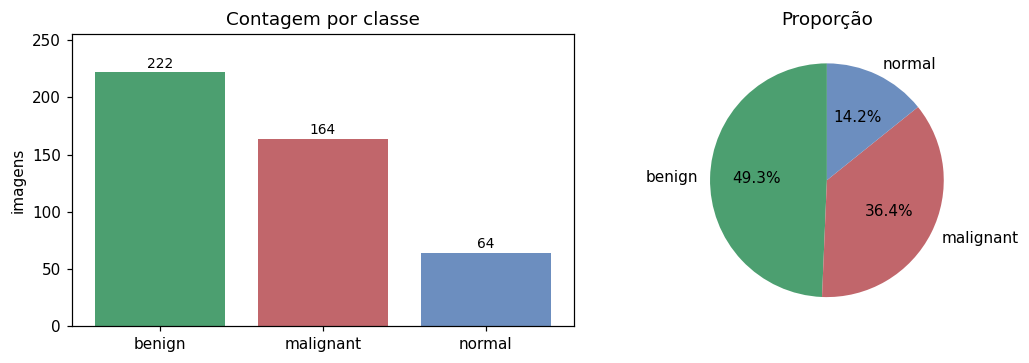

Razão maior/menor classe: 3.47x  (benign=222 vs normal=64)


In [5]:
dist = mapping['class'].value_counts().reindex(CLASSES)
bal = pd.DataFrame({'imagens': dist, 'proporção': (dist / dist.sum()).round(4)})
bal.loc['TOTAL'] = [dist.sum(), 1.0]
display(bal)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].bar(dist.index, dist.values, color=[COLORS[c] for c in dist.index])
for i, v in enumerate(dist.values):
    ax[0].text(i, v + 4, str(v), ha='center', fontsize=9)
ax[0].set_title('Contagem por classe'); ax[0].set_ylabel('imagens')
ax[0].set_ylim(0, dist.max() * 1.15)

ax[1].pie(dist.values, labels=dist.index, autopct='%1.1f%%',
          colors=[COLORS[c] for c in dist.index], startangle=90)
ax[1].set_title('Proporção')
plt.tight_layout(); plt.show()

print(f"Razão maior/menor classe: {dist.max() / dist.min():.2f}x  "
      f"({dist.idxmax()}={dist.max()} vs {dist.idxmin()}={dist.min()})")

Desbalanceamento moderado (~3.5x). É o que `data.oversampling` trata: o `deterministic_oversampling`
replica cada classe por `round(1/proporção)` no fold de treino.

**`normal` é um caso à parte**: suas máscaras são vazias por definição (não há tumor), então essa
classe é excluída da tarefa de segmentação via `data.seg_exclude_classes`. Sem isso, uma máscara
vazia daria Dice=1 de graça e inflaria a métrica.

In [6]:
# Efeito do oversampling no fold de treino (o que o modelo realmente vê)
from src.dataset.BUSI_dataloader import deterministic_oversampling

train_fold0 = partition[(partition.fold == 0) & (partition.task == 'cls') & (partition.split == 'train')]
antes = train_fold0['class'].value_counts().reindex(CLASSES)
depois = deterministic_oversampling(train_fold0)['class'].value_counts().reindex(CLASSES)

comp = pd.DataFrame({'antes': antes, 'depois': depois,
                     'prop. antes': (antes / antes.sum()).round(3),
                     'prop. depois': (depois / depois.sum()).round(3)})
comp.loc['TOTAL'] = [antes.sum(), depois.sum(), 1.0, 1.0]
print('Clientes cls, fold 0, split=train (uniao dos 2 clientes):')
display(comp)
print(f"Razao maior/menor -- antes: {antes.max()/antes.min():.2f}x  ->  depois: {depois.max()/depois.min():.2f}x")

Clientes cls, fold 0, split=train (uniao dos 2 clientes):


,antes,depois,prop. antes,prop. depois
benign,132.0,264.0,0.493,0.320
malignant,98.0,294.0,0.366,0.357
normal,38.0,266.0,0.142,0.323
TOTAL,268.0,824.0,1.000,1.000


Razao maior/menor -- antes: 3.47x  ->  depois: 1.11x


## 3. Características das imagens

In [7]:
print('Dimensões (dim1 x dim2):', mapping[['dim1', 'dim2']].drop_duplicates().to_dict('records'))
print('Todas 128x128         :', bool(((mapping.dim1 == 128) & (mapping.dim2 == 128)).all()))
print()

carac = mapping.groupby('class')[['tumor_pixels', 'y_size', 'x_size']].agg(['mean', 'std', 'min', 'max'])
carac.round(1)

Dimensões (dim1 x dim2): [{'dim1': 128, 'dim2': 128}]
Todas 128x128         : True



tumor_pixels                   y_size  ...      x_size               
                  mean     std min   max   mean  ...  max   mean   std min  max
class                                            ...                           
benign          1082.2  1288.0  47  7350   27.6  ...   82   41.2  26.4   8  117
malignant       2575.9  1818.3  85  9229   56.1  ...  114   64.6  25.5  12  123
normal             0.0     0.0   0     0    0.0  ...    0    0.0   0.0   0    0

[3 rows x 12 columns]

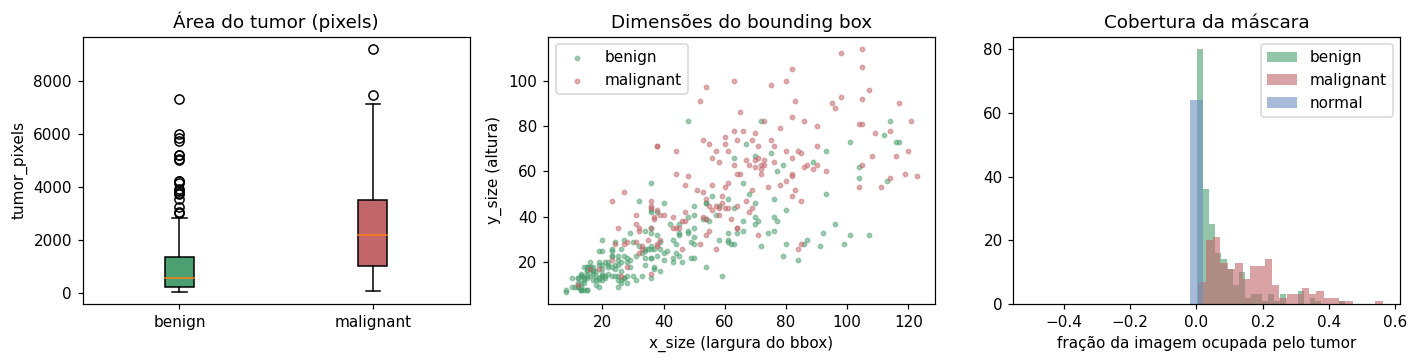

tumor_pixels == 0 por classe (esperado: só normal):
normal    64


In [8]:
seg_rows = mapping[mapping['class'] != 'normal']   # normal tem máscara vazia

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

data = [seg_rows[seg_rows['class'] == c]['tumor_pixels'].values for c in ['benign', 'malignant']]
bp = ax[0].boxplot(data, labels=['benign', 'malignant'], patch_artist=True)
for patch, c in zip(bp['boxes'], ['benign', 'malignant']):
    patch.set_facecolor(COLORS[c])
ax[0].set_title('Área do tumor (pixels)'); ax[0].set_ylabel('tumor_pixels')

for c in ['benign', 'malignant']:
    sub = seg_rows[seg_rows['class'] == c]
    ax[1].scatter(sub.x_size, sub.y_size, s=8, alpha=.5, label=c, color=COLORS[c])
ax[1].set_xlabel('x_size (largura do bbox)'); ax[1].set_ylabel('y_size (altura)')
ax[1].set_title('Dimensões do bounding box'); ax[1].legend()

frac = (mapping.tumor_pixels / (mapping.dim1 * mapping.dim2))
for c in CLASSES:
    ax[2].hist(frac[mapping['class'] == c], bins=25, alpha=.6, label=c, color=COLORS[c])
ax[2].set_xlabel('fração da imagem ocupada pelo tumor'); ax[2].set_title('Cobertura da máscara')
ax[2].legend()
plt.tight_layout(); plt.show()

print('tumor_pixels == 0 por classe (esperado: só normal):')
print(mapping[mapping.tumor_pixels == 0]['class'].value_counts().to_string())

Tumores malignos são maiores e mais variáveis em área que os benignos — coerente com a literatura, e
um sinal que o classificador pode explorar. As 64 imagens `normal` são exatamente as de
`tumor_pixels == 0`, confirmando que a máscara vazia é a marca dessa classe.

## 4. Exemplos

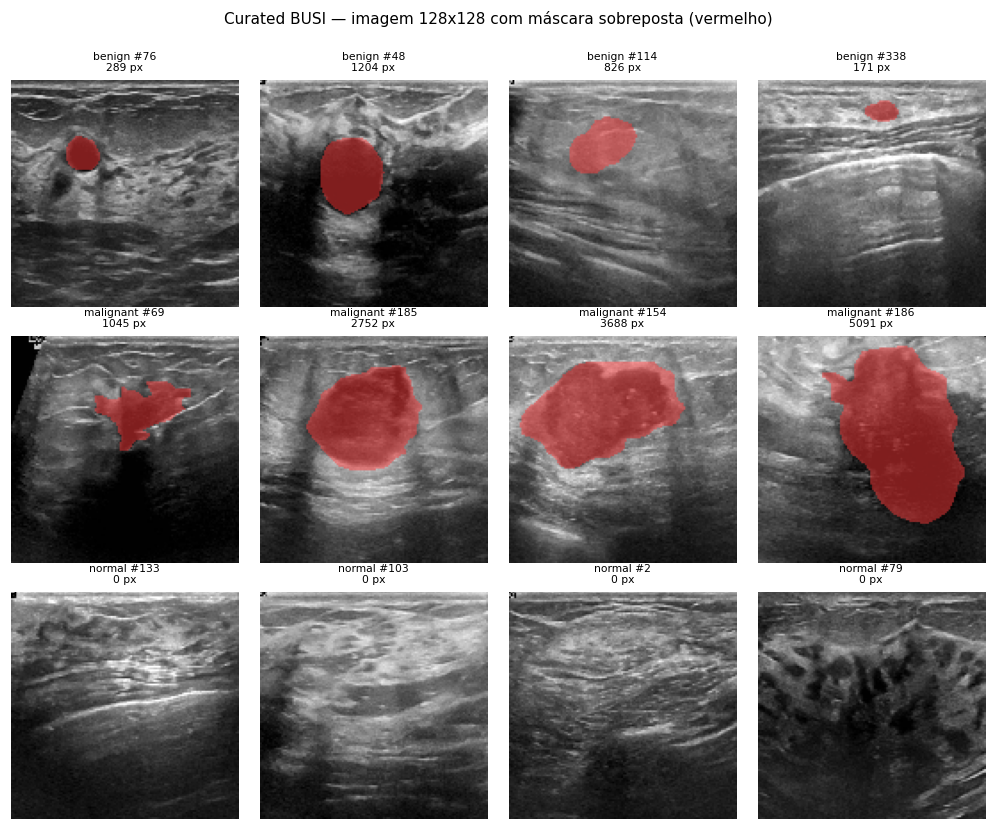

In [9]:
rng = np.random.default_rng(1993)
N = 4
fig, axes = plt.subplots(len(CLASSES), N, figsize=(2.3 * N, 2.5 * len(CLASSES)))

for r, cls in enumerate(CLASSES):
    sub = mapping[mapping['class'] == cls]
    picks = rng.choice(sub.index.values, N, replace=False)
    for c, idx in enumerate(picks):
        row = mapping.loc[idx]
        img = cv2.imread(row.img_path, 0)
        mask = cv2.imread(row.mask_path, 0)
        rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        rgb[mask > 0] = (0.5 * rgb[mask > 0] + 0.5 * np.array([255, 60, 60])).astype(np.uint8)
        axes[r, c].imshow(rgb)
        axes[r, c].set_title(f"{cls} #{row.id}\n{int(row.tumor_pixels)} px", fontsize=7)
        axes[r, c].axis('off')

plt.suptitle('Curated BUSI — imagem 128x128 com máscara sobreposta (vermelho)', y=1.0, fontsize=10)
plt.tight_layout(); plt.show()

## 5. Partição federada

`federated_mapping.csv` é a partição **congelada** — gerada uma vez e reutilizada pelos três setups
(federated / standalone / centralized), que é o que torna a comparação justa.

In [10]:
print('Clientes:', list(partition.client_id.unique()))
print()
print('Linhas por task x split (todos os folds):')
display(pd.crosstab(partition.task, partition.split, margins=True, margins_name='TOTAL'))

print('\nFold 0 — tamanho por cliente e split:')
display(pd.crosstab(partition[partition.fold == 0].client_id,
                    partition[partition.fold == 0].split,
                    margins=True, margins_name='TOTAL'))

Clientes: ['seg_0', 'seg_1', 'cls_0', 'cls_1']

Linhas por task x split (todos os folds):


split,test,train,val,TOTAL
task,,,,
cls,450,1075,275,1800
seg,386,922,236,1544
TOTAL,836,1997,511,3344



Fold 0 — tamanho por cliente e split:


split,test,train,val,TOTAL
client_id,,,,
cls_0,57,120,31,208
cls_1,56,148,38,242
seg_0,49,102,26,177
seg_1,48,128,33,209
TOTAL,210,498,128,836


In [11]:
f0 = partition[partition.fold == 0]
print('Fold 0 — distribuição de classes por cliente/split:')
display(pd.crosstab([f0.client_id, f0.split], f0['class']).fillna(0).astype(int))

Fold 0 — distribuição de classes por cliente/split:


class            benign  malignant  normal
client_id split                           
cls_0     test       28         21       8
          train      61         41      18
          val        16         10       5
cls_1     test       28         20       8
          train      71         57      20
          val        18         15       5
seg_0     test       28         21       0
          train      61         41       0
          val        16         10       0
seg_1     test       28         20       0
          train      71         57       0
          val        18         15       0

Note que os clientes `seg_*` não têm nenhuma linha `normal`: essa classe é removida da tarefa de
segmentação (`data.seg_exclude_classes: [normal]`), pelo motivo da máscara vazia explicado acima.
Os clientes `cls_*` mantêm as três classes.

O `dirichlet_alpha: 100.0` do config é alto, então a partição é ~IID — os clientes têm distribuições
de classe parecidas. Baixar esse alpha simularia heterogeneidade (non-IID).

In [12]:
# Sem vazamento: nenhuma imagem de teste pode aparecer em treino/val no mesmo fold
leaks = []
for fold in sorted(partition.fold.unique()):
    f = partition[partition.fold == fold]
    test = set(f[f.split == 'test'].img_path)
    trainval = set(f[f.split != 'test'].img_path)
    leaks.append({'fold': fold, 'imgs treino+val': len(trainval), 'imgs teste': len(test),
                  'sobreposição': len(test & trainval)})
leak_df = pd.DataFrame(leaks)
display(leak_df)
print('SEM VAZAMENTO' if leak_df['sobreposição'].sum() == 0
      else 'ATENÇÃO: há sobreposição treino/teste')

,fold,imgs treino+val,imgs teste,sobreposição
0,0,337,113,0
1,1,337,113,0
2,2,338,112,0
3,3,338,112,0


SEM VAZAMENTO


## 6. Resumo

In [13]:
print(f"""
Curated BUSI
------------
raw/                450 imagens (222 benign / 164 malignant / 64 normal) + 450 máscaras
                    ATENÇÃO: já é o subconjunto curado, não o BUSI completo (~780)
processed_128/      {len(mapping)} imagens 128x128 grayscale + máscaras binárias
federated/          {len(partition)} linhas = {partition.img_path.nunique()} imagens x {partition.fold.nunique()} folds x tarefas

Balanceamento       benign 49.3% / malignant 36.4% / normal 14.2%  ({dist.max()/dist.min():.1f}x maior:menor)
                    tratado por data.oversampling no fold de treino
Classe normal       máscara vazia por definição -> excluída da tarefa seg (seg_exclude_classes)
Clientes federados  {list(partition.client_id.unique())}
Vazamento treino/teste: {'nenhum' if leak_df['sobreposição'].sum() == 0 else 'DETECTADO'}
""")


Curated BUSI
------------
raw/                450 imagens (222 benign / 164 malignant / 64 normal) + 450 máscaras
                    ATENÇÃO: já é o subconjunto curado, não o BUSI completo (~780)
processed_128/      450 imagens 128x128 grayscale + máscaras binárias
federated/          3344 linhas = 450 imagens x 4 folds x tarefas

Balanceamento       benign 49.3% / malignant 36.4% / normal 14.2%  (3.5x maior:menor)
                    tratado por data.oversampling no fold de treino
Classe normal       máscara vazia por definição -> excluída da tarefa seg (seg_exclude_classes)
Clientes federados  ['seg_0', 'seg_1', 'cls_0', 'cls_1']
Vazamento treino/teste: nenhum

